<a href="https://colab.research.google.com/github/azzindani/Kestrel/blob/main/Kestrel_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# QT-1 — Clone / update repo + install deps (--deps-only skips .env/DB/exchange checks)
!git clone -b claude/fix-kestrel-colab-notebook-fqIDL https://github.com/azzindani/kestrel.git /content/kestrel 2>/dev/null || git -C /content/kestrel pull --ff-only
%cd /content/kestrel
!bash scripts/install.sh --deps-only

/content/kestrel
Checking Python version...
[GO] Python 3.12
Installing system packages...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  netbase postgresql-client-14 postgresql-client-common
Suggested packages:
  postgresql-14 postgresql-doc-14
The following NEW packages will be installed:
  netbase postgresql-client postgresql-client-14 postgresql-client-common
  python3.12-venv
0 upgraded, 5 newly installed, 0 to remove and 2 not upgraded.
Need to get 3,092 kB of archives.
After this operation, 6,360 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 netbase all 6.3 [12.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 postgresql-client-common all 238 [29.6 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 postgresql-client-14 amd64 14.22-0ubuntu0.22.04.1 [1,251 kB]
Get:4 https://ppa.launchpadcontent.net/deadsnakes/ppa

In [2]:
# QT-2 — Fetch 90 days BTC/USDT 5m candles + build indicators
# Fetch via script (tries bybit → okx → kucoin; no API key required).
import sys, os, json as _json, time
from collections import deque

sys.path.insert(0, '/content/kestrel')
os.chdir('/content/kestrel')

from src.config import Candle, compute_candle_geometry, load_params
from src.signal.indicators import compute_all_indicators

!python scripts/fetch_ohlcv.py --pair BTC/USDT --tf 5m --days 90 --out /tmp/ohlcv.json

ohlcvs = _json.loads(open('/tmp/ohlcv.json').read())
print(f'Loaded {len(ohlcvs):,} raw candles')

params, buf, candles = load_params('params.json'), deque(maxlen=120), []
for row in ohlcvs:
    ts, o, h, l, c, v = row
    geom = compute_candle_geometry(o, h, l, c)
    raw  = Candle(bot_id='qt', ts=ts, pair='BTCUSDT', timeframe='5m',
                  open=o, high=h, low=l, close=c, volume=v, **geom)
    buf.append(raw)
    inds = compute_all_indicators(list(buf), ema_fast=params.ema_fast, ema_slow=params.ema_slow)
    full = Candle(bot_id='qt', ts=ts, pair='BTCUSDT', timeframe='5m',
                  open=o, high=h, low=l, close=c, volume=v, **geom, **inds)
    buf[-1] = full
    candles.append(full)
print(f'OK  {len(candles):,} candles with indicators')

Fetching 90d BTC/USDT 5m via kucoin...
OK  25,920 candles
Written to /tmp/ohlcv.json
Loaded 25,920 raw candles
OK  25,920 candles with indicators


Debug window: 500 candles · 438 evaluations · 1 trades
Top rejection reasons:
  pattern     no_pattern_fired                                           251  (57%)
  regime      quiet_regime                                               173  (39%)
  trend       no_trend_alignment                                          11  (3%)
  volume      volume_ratio_below_threshold:0.991<1.560                     1  (0%)
  volume      volume_ratio_below_threshold:0.736<1.300                     1  (0%)

── Out-of-Sample Verdict ─────────────────────────────
  [FAIL]  Win rate > 55%                  40.0%
  [FAIL]  Avg PnL/trade > $0.018          $-0.3169
  [PASS]  Max drawdown < 30%              0.0%
  [FAIL]  Sharpe > 0                      -169.79
  [FAIL]  Trades >= 20                    10
  Close reasons: {'stop_loss': 5, 'timeout': 2, 'take_profit': 3}

  [NO-GO]


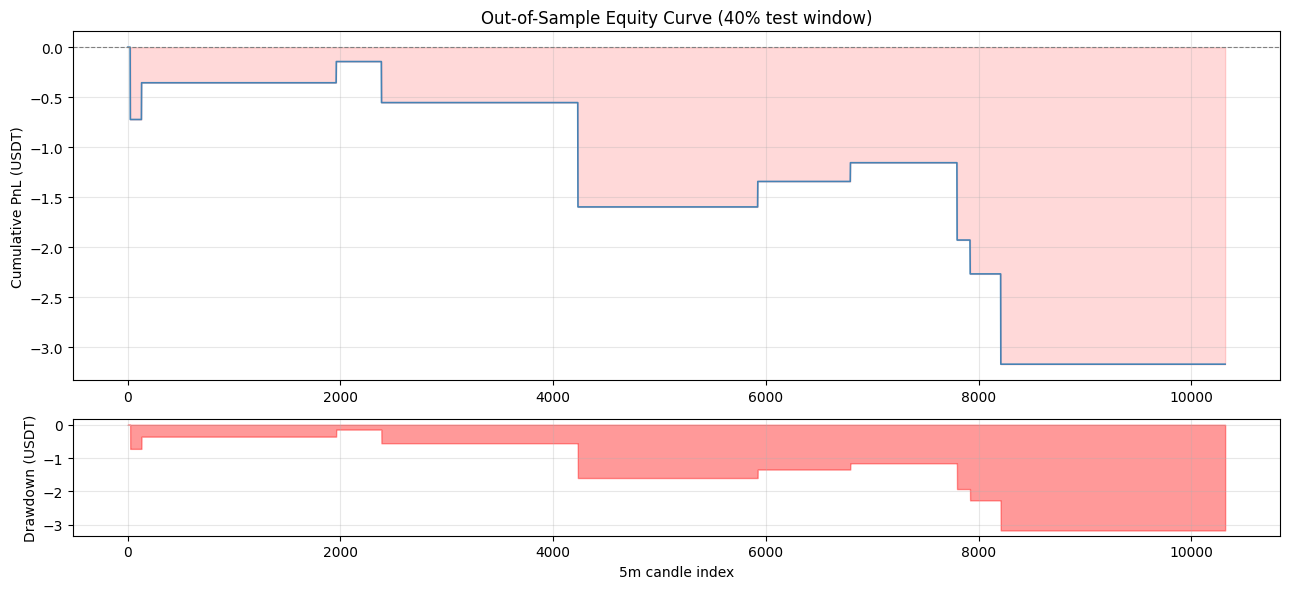

In [3]:
# QT-3 — Walk-forward backtest + verdict + equity curve
import os, matplotlib.pyplot as plt
from collections import Counter
from src.config import AppConfig
from src.backtest.runner import walk_forward, run_backtest

os.environ.update({
    'ENV':'dev','BOT_ID':'qt','EXCHANGE':'bybit',
    'API_KEY':'x','API_SECRET':'x','TESTNET':'true',
    'DB_HOST':'localhost','DB_PORT':'5432','DB_NAME':'kestrel',
    'DB_USER':'kestrel','DB_PASSWORD':'x',
    'PAIR':'BTCUSDT','TIMEFRAME_ENTRY':'5m','TIMEFRAME_REGIME':'15m',
    'LEVERAGE':'20','BUCKET_SIZE_USDT':'10.0','MAX_ACTIVE_BUCKETS':'1',
    'TELEGRAM_TOKEN':'x','TELEGRAM_CHAT_ID':'0','LOG_LEVEL':'DEBUG',
})
cfg = AppConfig.from_mapping(os.environ)

# ── Rejection breakdown (first 500 evaluated candles) ───────────────────
debug = run_backtest(candles[:500], params, cfg)
n_evals = len(debug['signals'])
print(f'Debug window: {len(candles[:500])} candles · {n_evals} evaluations · {len(debug["trades"])} trades')
if n_evals:
    reasons = Counter(
        (s.get('stage', '?'), s.get('reason', '?')[:55])
        for s in debug['signals'] if s.get('outcome') == 'rejected'
    )
    print('Top rejection reasons:')
    for (stage, reason), count in reasons.most_common(8):
        print(f'  {stage:10}  {reason:<55}  {count:5}  ({count/n_evals*100:.0f}%)')
print()

# ── Walk-forward ──────────────────────────────────────────────────────────
results = walk_forward(candles, params, cfg)
oos     = results['out_sample']

checks = [
    ('Win rate > 55%',         oos.get('win_rate',0) >= 0.55,  f'{oos.get("win_rate",0)*100:.1f}%'),
    ('Avg PnL/trade > $0.018', oos.get('avg_pnl_usdt',0) >= 0.018, f'${oos.get("avg_pnl_usdt",0):.4f}'),
    ('Max drawdown < 30%',     oos.get('max_drawdown_pct',100) <= 30, f'{oos.get("max_drawdown_pct",100):.1f}%'),
    ('Sharpe > 0',             oos.get('sharpe_ratio',0) > 0,   f'{oos.get("sharpe_ratio",0):.2f}'),
    ('Trades >= 20',           oos.get('total_trades',0) >= 20, f'{oos.get("total_trades",0)}'),
]
all_pass = True
print('── Out-of-Sample Verdict ─────────────────────────────')
for label, passed, val in checks:
    all_pass = all_pass and passed
    print(f'  [{"PASS" if passed else "FAIL"}]  {label:<30}  {val}')
print(f'  Close reasons: {oos.get("close_reasons",{})}')
print(f'\n  {"[GO]" if all_pass else "[NO-GO]"}')

split  = int(len(candles) * 0.6)
equity = run_backtest(candles[split:], params, cfg)['equity_curve']
peak   = 0.0
dds    = [((peak := max(peak, e)), e - peak)[1] for e in equity]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [3,1]})
ax1.plot(equity, lw=1.2, color='steelblue')
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.fill_between(range(len(equity)), equity, 0, where=[e>=0 for e in equity], alpha=0.15, color='green')
ax1.fill_between(range(len(equity)), equity, 0, where=[e<0  for e in equity], alpha=0.15, color='red')
ax1.set_title('Out-of-Sample Equity Curve (40% test window)', fontsize=12)
ax1.set_ylabel('Cumulative PnL (USDT)'); ax1.grid(True, alpha=0.3)
ax2.fill_between(range(len(dds)), dds, 0, color='red', alpha=0.4)
ax2.set_ylabel('Drawdown (USDT)'); ax2.set_xlabel('5m candle index'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
%%bash
# Cell 0 — Kill existing Kestrel processes + clean state
pkill -f "src.engine.daemon"   2>/dev/null || true
pkill -f "src.engine.watchdog" 2>/dev/null || true
sleep 2
rm -f /content/kestrel/kestrel.pid
echo "OK  Environment clean"

OK  Environment clean


In [5]:
# Cell 1 — Clone / update repo
!git clone -b claude/fix-kestrel-colab-notebook-fqIDL https://github.com/azzindani/kestrel.git /content/kestrel 2>/dev/null || git -C /content/kestrel pull --ff-only
%cd /content/kestrel

Already up to date.
/content/kestrel


In [6]:
# Cell 2 — Write .env from Colab Secrets
# Python required here — Colab Secrets are only accessible via google.colab.userdata.
# Set all keys in Colab > key icon > Secrets before running.
from google.colab import userdata
import pathlib

def _s(key, default=''):
    try:    v = userdata.get(key); return v if v else default
    except: return default

pathlib.Path('/content/kestrel/.env').write_text('\n'.join([
    'ENV=dev',
    'BOT_ID='           + _s('BOT_ID'),
    'EXCHANGE='         + _s('EXCHANGE'),
    'API_KEY='          + _s('API_KEY'),
    'API_SECRET='       + _s('API_SECRET'),
    'TESTNET=true',
    'DB_HOST='          + _s('DB_HOST'),
    'DB_PORT='          + _s('DB_PORT', '5432'),
    'DB_NAME='          + _s('DB_NAME'),
    'DB_USER='          + _s('DB_USER'),
    'DB_PASSWORD='      + _s('DB_PASSWORD'),
    'PAIR='             + _s('PAIR', 'BTCUSDT'),
    'TIMEFRAME_ENTRY=5m',
    'TIMEFRAME_REGIME=15m',
    'LEVERAGE=20',
    'BUCKET_SIZE_USDT=10.0',
    'MAX_ACTIVE_BUCKETS=1',
    'TELEGRAM_TOKEN='   + _s('TELEGRAM_TOKEN'),
    'TELEGRAM_CHAT_ID=' + _s('TELEGRAM_CHAT_ID'),
    'LOG_LEVEL=DEBUG',
]) + '\n')
print('OK  .env written')

OK  .env written


In [7]:
# Cell 3 — Install + validate  (must print [GO] — stop if [NO-GO])
!bash scripts/install.sh

Checking Python version...
[GO] Python 3.12
Installing system packages...
Reading package lists...
Building dependency tree...
Reading state information...
postgresql-client is already the newest version (14+238).
python3.12-venv is already the newest version (3.12.13-1+jammy1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
[GO] System packages (python3.12-venv, postgresql-client)
Setting up venv...
Installing dependencies (venv)...
[GO] Dependencies installed (venv)
Installing dependencies (system Python)...
[GO] Dependencies installed (system Python)
Checking .env...
[NO-GO] .env missing: BOT_ID


In [8]:
# Cell 4 — Start daemon  (ENV=dev · simulation · TESTNET=true · no real orders)
!bash scripts/start.sh

Starting Kestrel daemon (BOT_ID=, ENV=dev)...
Watchdog started (pid=10916). Daemon is supervised.
Logs: /content/kestrel/kestrel.log
Status: ./scripts/status.sh


In [9]:
# Cell 5 — Health check
!bash scripts/status.sh

=== Kestrel Status ===
  ✓ Watchdog running (pid=10916)
  ⚠ DB unreachable — cannot check heartbeat
  ⚠ DB unreachable — cannot check positions



In [10]:
# Cell M1 — Recent events (last 20)
!bash scripts/logs.sh --no-follow

[WARN]  DB unreachable — cannot stream events (gaierror: [Errno -2] Name or service not known)


In [11]:
%%bash
# Cell M2 — Session statistics
source /content/kestrel/.env
PGPASSWORD=
DB_HOST -p
DB_USER -d $DB_NAME -x -c "
SELECT
    COUNT(*)                                                     AS total_trades,
    COUNT(*) FILTER (WHERE exit_ts IS NOT NULL)                  AS closed,
    COUNT(*) FILTER (WHERE exit_ts IS NULL)                      AS open,
    COUNT(*) FILTER (WHERE pnl_net_usdt > 0)                     AS wins,
    ROUND(
        COUNT(*) FILTER (WHERE pnl_net_usdt > 0)::numeric /
        NULLIF(COUNT(*) FILTER (WHERE exit_ts IS NOT NULL), 0) * 100, 1
    )                                                            AS win_rate_pct,
    ROUND(COALESCE(SUM(pnl_net_usdt)
        FILTER (WHERE exit_ts IS NOT NULL), 0)::numeric, 4)      AS total_pnl_usdt,
    ROUND(COALESCE(AVG(pnl_pct)
        FILTER (WHERE pnl_net_usdt > 0),  0)::numeric, 2)        AS avg_win_pct,
    ROUND(COALESCE(AVG(pnl_pct)
        FILTER (WHERE pnl_net_usdt <= 0 AND exit_ts IS NOT NULL),
        0)::numeric, 2)                                          AS avg_loss_pct
FROM trades
WHERE bot_id='$BOT_ID' AND env='dev';"

bash: line 4: DB_HOST: command not found
bash: line 5: DB_USER: command not found


CalledProcessError: Command 'b'# Cell M2 \xe2\x80\x94 Session statistics\nsource /content/kestrel/.env\nPGPASSWORD=\nDB_HOST -p\nDB_USER -d $DB_NAME -x -c "\nSELECT\n    COUNT(*)                                                     AS total_trades,\n    COUNT(*) FILTER (WHERE exit_ts IS NOT NULL)                  AS closed,\n    COUNT(*) FILTER (WHERE exit_ts IS NULL)                      AS open,\n    COUNT(*) FILTER (WHERE pnl_net_usdt > 0)                     AS wins,\n    ROUND(\n        COUNT(*) FILTER (WHERE pnl_net_usdt > 0)::numeric /\n        NULLIF(COUNT(*) FILTER (WHERE exit_ts IS NOT NULL), 0) * 100, 1\n    )                                                            AS win_rate_pct,\n    ROUND(COALESCE(SUM(pnl_net_usdt)\n        FILTER (WHERE exit_ts IS NOT NULL), 0)::numeric, 4)      AS total_pnl_usdt,\n    ROUND(COALESCE(AVG(pnl_pct)\n        FILTER (WHERE pnl_net_usdt > 0),  0)::numeric, 2)        AS avg_win_pct,\n    ROUND(COALESCE(AVG(pnl_pct)\n        FILTER (WHERE pn

In [12]:
%%bash
# Cell M3 — Open positions
source /content/kestrel/.env
PGPASSWORD=
DB_HOST -p
DB_USER -d $DB_NAME -c "
SELECT pair, direction, pattern, leverage,
       entry_price, tp_price, sl_price, liquidation_price, size_usdt,
       to_timestamp(entry_ts / 1000)::time AS opened_at
FROM trades
WHERE bot_id='$BOT_ID' AND env='dev' AND exit_ts IS NULL
ORDER BY entry_ts DESC;"

bash: line 4: DB_HOST: command not found
bash: line 5: DB_USER: command not found


CalledProcessError: Command 'b'# Cell M3 \xe2\x80\x94 Open positions\nsource /content/kestrel/.env\nPGPASSWORD=\nDB_HOST -p\nDB_USER -d $DB_NAME -c "\nSELECT pair, direction, pattern, leverage,\n       entry_price, tp_price, sl_price, liquidation_price, size_usdt,\n       to_timestamp(entry_ts / 1000)::time AS opened_at\nFROM trades\nWHERE bot_id=\'$BOT_ID\' AND env=\'dev\' AND exit_ts IS NULL\nORDER BY entry_ts DESC;"\n'' returned non-zero exit status 127.

In [13]:
# Cell M4 — Follow live event stream  (interrupt kernel to stop)
!bash scripts/logs.sh --follow

[WARN]  DB unreachable — cannot stream events (gaierror: [Errno -2] Name or service not known)


In [14]:
# Cell C1 — Daemon status
!bash scripts/status.sh

=== Kestrel Status ===
  ✓ Watchdog running (pid=10916)
  ⚠ DB unreachable — cannot check heartbeat
  ⚠ DB unreachable — cannot check positions



In [15]:
# Cell C2 — Restart daemon  (graceful stop → wait → fresh start)
!bash scripts/restart.sh

Stopping...
Sending SIGTERM to watchdog (pid=10916)...
Daemon stopped cleanly.
Waiting 3s...
Starting...
Starting Kestrel daemon (BOT_ID=, ENV=dev)...
Watchdog started (pid=12365). Daemon is supervised.
Logs: /content/kestrel/kestrel.log
Status: ./scripts/status.sh


In [16]:
# Cell C3 — Graceful stop  (closes all positions before exit)
!bash scripts/stop.sh

Sending SIGTERM to watchdog (pid=12365)...
Daemon stopped cleanly.


In [17]:
# Cell A — Fetch 90 days BTC/USDT 5m  (public Binance — no auth)
import ccxt, time

PAIR, TIMEFRAME, DAYS = 'BTC/USDT', '5m', 90
exchange = ccxt.binance({'enableRateLimit': True})
since    = int((time.time() - DAYS * 86400) * 1000)
ohlcvs   = []

print(f'Fetching {DAYS}d of {PAIR} {TIMEFRAME}...')
while True:
    batch = exchange.fetch_ohlcv(PAIR, TIMEFRAME, since=since, limit=1000)
    if not batch: break
    ohlcvs.extend(batch)
    since = batch[-1][0] + 1
    if len(batch) < 1000: break
    print(f'  {len(ohlcvs):,}...', end='\r')
print(f'OK  {len(ohlcvs):,} candles  ({len(ohlcvs)*5/60/24:.1f} days)')

Fetching 90d of BTC/USDT 5m...


ExchangeNotAvailable: binance GET https://api.binance.com/api/v3/exchangeInfo 451  {
  "code": 0,
  "msg": "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message in error."
}

In [18]:
# Cell B — Build Candle objects + indicators
import sys, os
sys.path.insert(0, '/content/kestrel')
os.chdir('/content/kestrel')

from collections import deque
from src.config import Candle, compute_candle_geometry, load_params
from src.signal.indicators import compute_all_indicators

params, buf, candles = load_params('params.json'), deque(maxlen=120), []
for i, row in enumerate(ohlcvs):
    ts, o, h, l, c, v = row
    geom = compute_candle_geometry(o, h, l, c)
    raw  = Candle(bot_id='backtest', ts=ts, pair='BTCUSDT', timeframe='5m',
                  open=o, high=h, low=l, close=c, volume=v, **geom)
    buf.append(raw)
    inds = compute_all_indicators(list(buf), ema_fast=params.ema_fast, ema_slow=params.ema_slow)
    full = Candle(bot_id='backtest', ts=ts, pair='BTCUSDT', timeframe='5m',
                  open=o, high=h, low=l, close=c, volume=v, **geom, **inds)
    buf[-1] = full; candles.append(full)
    if (i+1) % 5000 == 0: print(f'  {i+1:,}/{len(ohlcvs):,}...', end='\r')
print(f'OK  {len(candles):,} candles with indicators')

OK  0 candles with indicators


In [19]:
# Cell C — Indicator sanity checks
from src.signal.indicators import compute_ema, compute_rsi, compute_atr

closes = [c.close for c in candles[-50:]]
ema9, ema21 = compute_ema(closes, 9), compute_ema(closes, 21)
rsi, atr    = compute_rsi(closes, 14), compute_atr(candles[-20:], 14)

assert 0 < rsi < 100 and atr > 0
print(f'OK  EMA9={ema9:.2f}  EMA21={ema21:.2f}  RSI14={rsi:.1f}  ATR14={atr:.2f}')
for reg in ('TRENDING','VOLATILE','RANGING','QUIET'):
    n = sum(1 for c in candles[-500:] if c.regime == reg)
    print(f'  {reg:10}  {n:4d} / 500  ({n/5:.0f}%)')

AssertionError: 

In [20]:
# Cell D — Walk-forward backtest  (60% train / 40% test)
import os
from dotenv import load_dotenv
load_dotenv('/content/kestrel/.env')
from src.config import AppConfig
from src.backtest.runner import walk_forward

cfg     = AppConfig.from_mapping(os.environ)
results = walk_forward(candles, params, cfg)

print('IN-SAMPLE:')
for k, v in results['in_sample'].items():  print(f'  {k:<32} {v}')
print('\nOUT-OF-SAMPLE:')
for k, v in results['out_sample'].items(): print(f'  {k:<32} {v}')

IN-SAMPLE:
  total_trades                     0
  win_count                        0
  loss_count                       0
  win_rate                         0.0
  total_pnl_usdt                   0.0
  avg_pnl_usdt                     0.0
  avg_win_usdt                     0.0
  avg_loss_usdt                    0.0
  profit_factor                    None
  sharpe_ratio                     0.0
  max_drawdown_usdt                0.0
  max_drawdown_pct                 0.0
  avg_hold_candles                 0.0
  close_reasons                    {}

OUT-OF-SAMPLE:
  total_trades                     0
  win_count                        0
  loss_count                       0
  win_rate                         0.0
  total_pnl_usdt                   0.0
  avg_pnl_usdt                     0.0
  avg_win_usdt                     0.0
  avg_loss_usdt                    0.0
  profit_factor                    None
  sharpe_ratio                     0.0
  max_drawdown_usdt                0.0
  max_dra

In [21]:
# Cell E — Out-of-sample verdict
oos = results['out_sample']
checks = [
    ('Win rate > 55%',         oos.get('win_rate',0) >= 0.55,  f'{oos.get("win_rate",0)*100:.1f}%'),
    ('Avg PnL/trade > $0.018', oos.get('avg_pnl_usdt',0) >= 0.018, f'${oos.get("avg_pnl_usdt",0):.4f}'),
    ('Max drawdown < 30%',     oos.get('max_drawdown_pct',100) <= 30, f'{oos.get("max_drawdown_pct",100):.1f}%'),
    ('Sharpe > 0',             oos.get('sharpe_ratio',0) > 0,   f'{oos.get("sharpe_ratio",0):.2f}'),
    ('Trades >= 20',           oos.get('total_trades',0) >= 20, f'{oos.get("total_trades",0)}'),
]
all_pass = True
print('── Out-of-Sample Verdict ─────────────────────────────')
for label, passed, val in checks:
    all_pass = all_pass and passed
    print(f'  [{"PASS" if passed else "FAIL"}]  {label:<30}  {val}')
print(f'  Close reasons: {oos.get("close_reasons",{})}')
print(f'\n  {"[GO]" if all_pass else "[NO-GO]"}')

── Out-of-Sample Verdict ─────────────────────────────
  [FAIL]  Win rate > 55%                  0.0%
  [FAIL]  Avg PnL/trade > $0.018          $0.0000
  [PASS]  Max drawdown < 30%              0.0%
  [FAIL]  Sharpe > 0                      0.00
  [FAIL]  Trades >= 20                    0
  Close reasons: {}

  [NO-GO]


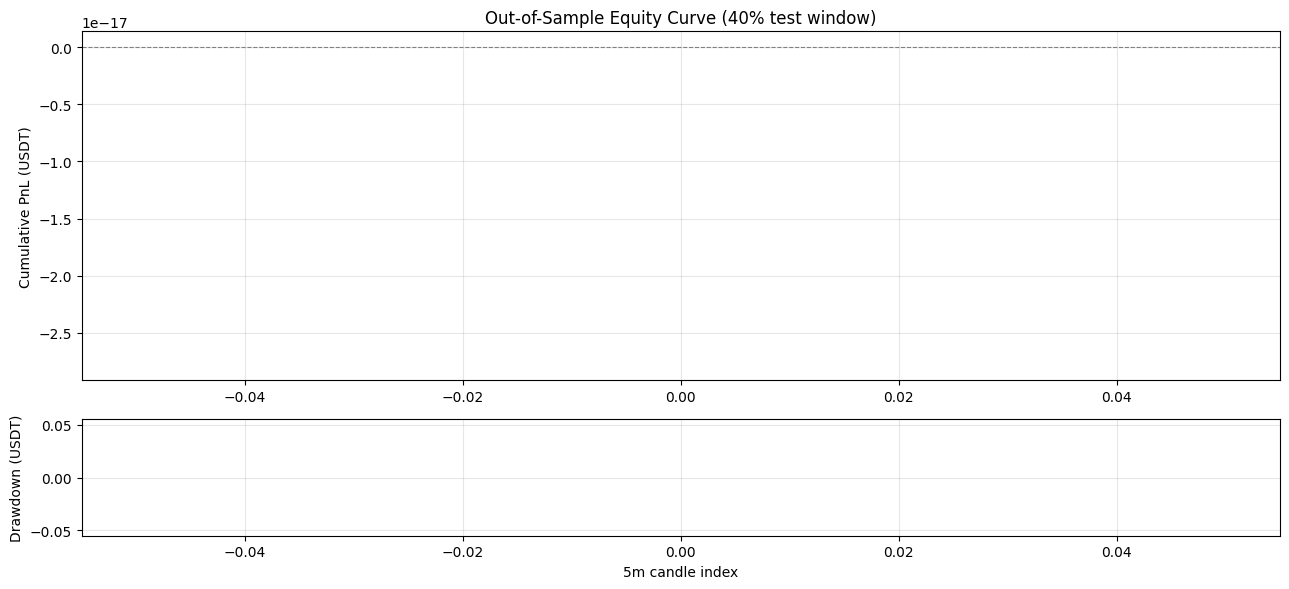

Peak: $0.0000  Final: $0.0000  Max DD: $0.0000


In [22]:
# Cell F — Out-of-sample equity curve + drawdown
import matplotlib.pyplot as plt
from src.backtest.runner import run_backtest

split  = int(len(candles) * 0.6)
equity = run_backtest(candles[split:], params, cfg)['equity_curve']
peak   = 0.0
dds    = [((peak := max(peak, e)), e - peak)[1] for e in equity]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [3,1]})
ax1.plot(equity, lw=1.2, color='steelblue')
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.fill_between(range(len(equity)), equity, 0, where=[e>=0 for e in equity], alpha=0.15, color='green')
ax1.fill_between(range(len(equity)), equity, 0, where=[e<0  for e in equity], alpha=0.15, color='red')
ax1.set_title('Out-of-Sample Equity Curve (40% test window)', fontsize=12)
ax1.set_ylabel('Cumulative PnL (USDT)'); ax1.grid(True, alpha=0.3)
ax2.fill_between(range(len(dds)), dds, 0, color='red', alpha=0.4)
ax2.set_ylabel('Drawdown (USDT)'); ax2.set_xlabel('5m candle index'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Peak: ${max(equity) if equity else 0:.4f}  Final: ${equity[-1] if equity else 0:.4f}  Max DD: ${min(dds) if dds else 0:.4f}')